# Wavepacket S(v) — **synthesis, σ_WP = 2 Bohr**

Quantum S(v) across the four production velocities (the classical benchmark is shown for orientation only — it exists at σ_WP = 0.5, not at this σ).

The curve has four points (v = 2.0, 2.5, 3.0, 3.5), matching the σ = 0.5
campaign's grid. Unlike that campaign, the exclusion of v = 4.0/4.5 does **not**
apply here: σ_p = 1/(√2σ) = 0.354 Bohr⁻¹ against k_Nyq = 7.85, so
aliasing is zero to machine precision at every velocity. The grid is held fixed
purely for point-for-point comparability.


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "/rds/user/skcb2/hpc-work/tddft/inq-tddft-research/ResearchProject/systems/localised_jellium/hypotheses/wp_highdensity_sv")
import wp_hd_stopping as W
W.set_campaign(2.0)
print("campaign:", W.campaign_label(), " fit window t <=", W.FIT_T1, "a.u.")

rows = []
for v in W.VELOCITIES:
    try:
        run = W.load_run(v)
    except FileNotFoundError as e:
        print(f"v={v}: MISSING ({e})"); continue
    t0, t1 = W.slab_window(v)
    slab = W.fit_all_in_slab(run, v)      # centroid INSIDE the medium — the physical S
    loc  = W.fit_all(run)                 # localised window — diagnostic only
    i_ex = int(np.argmin(np.abs(run.t - t1)))
    d = dict(v=v, t_in=round(t0, 2), t_out=round(t1, 2),
             norm_at_slab_exit=run.norm[i_ex], norm_end=run.norm[-1]/run.norm[0],
             aliasing_sigma_pz2_pct=W.aliasing_bias_pct(v)["sigma_pz2_err_pct"])
    for k, f in slab.items():
        d[k] = f.S_ev_per_bohr            # S_13 .. S_24, IN-SLAB
    d["broadening_S13_minus_S23"] = slab["S_13"].S_ev_per_bohr - slab["S_23"].S_ev_per_bohr
    dep = W.deposit_stopping(v)           # classical Definition 2 applied to the WP
    d.update(dep)
    for k, f in loc.items():
        d[k + "_localised"] = f.S_ev_per_bohr
    rows.append(d)
q = pd.DataFrame(rows)
display(q.round(4))
q.to_csv("wp_S_summary_s2p0.csv", index=False)
print("wrote wp_S_summary_s2p0.csv")
print()
print("S_1j uses the FULL orbital KE <p^2>/2m; S_2j the DRIFT only <p>^2/2m.")
print(f"The *_localised columns are the [{W.FIT_T0}, {W.FIT_T1}] a.u. window, which sits BEFORE")
print("the packet reaches the slab (11.5 Bohr standoff) and is therefore negative")
print("— it measures acceleration down the slab's attractive gradient, not stopping.")

campaign: sigma_WP = 2 Bohr  fit window t <= 16.01 a.u.


,v,t_in,t_out,norm_at_slab_exit,norm_end,aliasing_sigma_pz2_pct,S_13,S_14,S_23,S_24,...,S_deposit_corrected,norm_final,t_final_au,steps_done,steps_target,complete,S_13_localised,S_14_localised,S_23_localised,S_24_localised
0,2.0,5.75,18.25,0.9979,0.0,0.0,0.2269,0.2266,0.2486,0.2482,...,0.3553,0.0,144.92,3623,3623,True,-0.1215,-0.1215,-0.0522,-0.0522
1,2.5,4.60,14.60,0.9998,0.0,0.0,0.1812,0.1811,0.2255,0.2254,...,0.3592,0.0,115.92,2898,2898,True,-0.1678,-0.1678,-0.1052,-0.1052
2,3.0,3.83,12.17,1.0000,0.0,0.0,0.1368,0.1368,0.1923,0.1922,...,0.2916,0.0,96.60,2415,2415,True,-0.2256,-0.2256,-0.1681,-0.1681
3,3.5,3.29,10.43,0.9999,0.0,0.0,0.1014,0.1014,0.1619,0.1618,...,0.2185,0.0,82.80,2070,2070,True,-0.2627,-0.2627,-0.2101,-0.2101


wrote wp_S_summary_s2p0.csv

S_1j uses the FULL orbital KE <p^2>/2m; S_2j the DRIFT only <p>^2/2m.
The *_localised columns are the [0.5, 16.01] a.u. window, which sits BEFORE
the packet reaches the slab (11.5 Bohr standoff) and is therefore negative
— it measures acceleration down the slab's attractive gradient, not stopping.


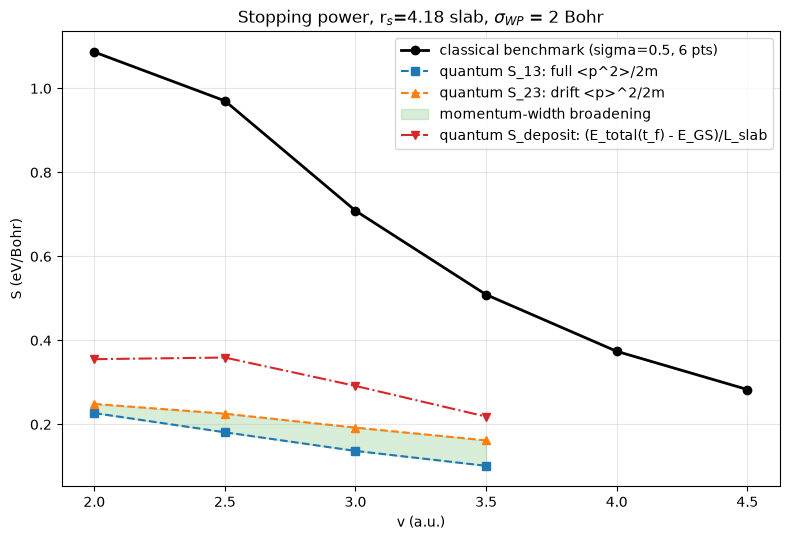

wrote wp_vs_classical_Sv_s2p0.png


In [2]:
cl = W.classical_reference()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(cl.v, cl.S_eV_per_Bohr, "ko-", lw=2,
        label="classical benchmark (sigma=0.5, 6 pts)")
ax.plot(q.v, q.S_13, "C0s--", label="quantum S_13: full <p^2>/2m")
ax.plot(q.v, q.S_23, "C1^--", label="quantum S_23: drift <p>^2/2m")
ax.fill_between(q.v, q.S_23, q.S_13, color="C2", alpha=0.18,
                label="momentum-width broadening")
ax.plot(q.v, q.S_deposit_corrected, "C3v-.",
        label="quantum S_deposit: (E_total(t_f) - E_GS)/L_slab")
ax.set(xlabel="v (a.u.)", ylabel="S (eV/Bohr)",
       title="Stopping power, r$_s$=4.18 slab, $\\sigma_{WP}$ = 2 Bohr")
ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig("wp_vs_classical_Sv_s2p0.png", dpi=140); plt.show()
print("wrote wp_vs_classical_Sv_s2p0.png")

## The third quantum curve — the classical estimator applied to the wavepacket

`S_deposit = (E_total(t_final) - E_GS)/L_slab` is the SAME formula the classical
benchmark uses, now evaluated on the wavepacket runs (E_GS = the dx = 0.40
production ground state, L_slab = 25 Bohr). It is plotted from the **norm-corrected**
ledger.

It comes out far BELOW the classical curve, and that is expected rather than a
discrepancy. Classically the projectile is an *external perturbation*: it is never
in the electronic ledger, and the CAP-free z-open box lets it leave without taking
ledger energy with it, so `plateau - E_GS` is purely the slab's gain. Here the
wavepacket **is** part of the system and the CAP **removes** it, so
`E_total(t_final) - E_GS` is only what is still in the box once everything the CAP
absorbed has already been subtracted. It is a **lower bound** on the deposit.

The raw-vs-corrected contrast is worth noting on its own: on INQ's uncorrected
ledger this estimator is velocity-INDEPENDENT at ~2.44 eV/Bohr — unphysical, since
S must fall with v here — because the norm-divided kinetic term dominates the
residual. After the correction it falls monotonically, as it must. Both are in the
CSV (`S_deposit_raw`, `S_deposit_corrected`).

## Reading this comparison honestly

The classical S is an **energy-deposit** measure, `(E_total(plateau) − E_GS)/L_slab`,
read after the projectile has fully left the box. The quantum S is
`−dT/ds` of the projectile orbital over a short early window. They address the
same physics but are not the same estimator, and the quantum one is additionally
limited by the transverse-overlap window, CAP attrition, and momentum aliasing
documented in each run notebook. Differences between the two curves should not be
attributed to quantum effects without first accounting for those three.
